In [1]:
import warnings
warnings.filterwarnings('ignore')
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import os
import matplotlib.pyplot as plt
from matplotlib.image import imread

import tensorflow as tf
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Dense, Flatten, Activation, GlobalMaxPooling2D
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.applications.xception import Xception, preprocess_input

from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split

2025-08-30 11:16:45.125551: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1756552605.481200      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1756552605.578553      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("kmader/rsna-bone-age")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/rsna-bone-age


In [3]:
dataframe_direction = "/kaggle/input/rsna-bone-age"
print(os.listdir(dataframe_direction))

['boneage-training-dataset.csv', 'boneage-training-dataset', 'boneage-test-dataset', 'boneage-test-dataset.csv']


TRAIN

In [4]:
training_dataframe = pd.read_csv("/kaggle/input/rsna-bone-age/boneage-training-dataset.csv")
training_dataframe["path"] = training_dataframe["id"].map(lambda x: os.path.join(dataframe_direction,"boneage-training-dataset","boneage-training-dataset","{}.png".format(x)))

print(training_dataframe)

          id  boneage   male  \
0       1377      180  False   
1       1378       12  False   
2       1379       94  False   
3       1380      120   True   
4       1381       82  False   
...      ...      ...    ...   
12606  15605       50  False   
12607  15606      113  False   
12608  15608       55  False   
12609  15609      150   True   
12610  15610      132   True   

                                                    path  
0      /kaggle/input/rsna-bone-age/boneage-training-d...  
1      /kaggle/input/rsna-bone-age/boneage-training-d...  
2      /kaggle/input/rsna-bone-age/boneage-training-d...  
3      /kaggle/input/rsna-bone-age/boneage-training-d...  
4      /kaggle/input/rsna-bone-age/boneage-training-d...  
...                                                  ...  
12606  /kaggle/input/rsna-bone-age/boneage-training-d...  
12607  /kaggle/input/rsna-bone-age/boneage-training-d...  
12608  /kaggle/input/rsna-bone-age/boneage-training-d...  
12609  /kaggle/input/rsna

In [5]:
training_dataframe["imagepath"] = training_dataframe["id"].map(lambda x: "{}.png".format(x))

In [6]:
training_dataframe["gender"] = training_dataframe["male"].map(lambda x: "male" if x else "female")

print(training_dataframe)

          id  boneage   male  \
0       1377      180  False   
1       1378       12  False   
2       1379       94  False   
3       1380      120   True   
4       1381       82  False   
...      ...      ...    ...   
12606  15605       50  False   
12607  15606      113  False   
12608  15608       55  False   
12609  15609      150   True   
12610  15610      132   True   

                                                    path  imagepath  gender  
0      /kaggle/input/rsna-bone-age/boneage-training-d...   1377.png  female  
1      /kaggle/input/rsna-bone-age/boneage-training-d...   1378.png  female  
2      /kaggle/input/rsna-bone-age/boneage-training-d...   1379.png  female  
3      /kaggle/input/rsna-bone-age/boneage-training-d...   1380.png    male  
4      /kaggle/input/rsna-bone-age/boneage-training-d...   1381.png  female  
...                                                  ...        ...     ...  
12606  /kaggle/input/rsna-bone-age/boneage-training-d...  15605.png  

In [7]:
training_dataframe["gender_encoded"] = training_dataframe["gender"].map(lambda x:1 if x == "male" else 0)
training_dataframe["boneage_category"] = pd.cut(training_dataframe["boneage"],10)

In [8]:
boneage_std = 2*training_dataframe["boneage"].std()
boneage_mean = training_dataframe["boneage"].mean()


training_dataframe["norm_age"] = (training_dataframe["boneage"] - boneage_mean) / boneage_std

print(training_dataframe)

          id  boneage   male  \
0       1377      180  False   
1       1378       12  False   
2       1379       94  False   
3       1380      120   True   
4       1381       82  False   
...      ...      ...    ...   
12606  15605       50  False   
12607  15606      113  False   
12608  15608       55  False   
12609  15609      150   True   
12610  15610      132   True   

                                                    path  imagepath  gender  \
0      /kaggle/input/rsna-bone-age/boneage-training-d...   1377.png  female   
1      /kaggle/input/rsna-bone-age/boneage-training-d...   1378.png  female   
2      /kaggle/input/rsna-bone-age/boneage-training-d...   1379.png  female   
3      /kaggle/input/rsna-bone-age/boneage-training-d...   1380.png    male   
4      /kaggle/input/rsna-bone-age/boneage-training-d...   1381.png  female   
...                                                  ...        ...     ...   
12606  /kaggle/input/rsna-bone-age/boneage-training-d...  1560

TEST

In [9]:
testing_dataframe = pd.read_csv("/kaggle/input/rsna-bone-age/boneage-test-dataset.csv")
testing_dataframe["path"] = testing_dataframe["Case ID"].map(lambda x: os.path.join(dataframe_direction,"boneage-test-dataset","boneage-test-dataset","{}.png".format(x)))

testing_dataframe["imagepath"] = testing_dataframe["Case ID"].map(lambda x: "{}.png".format(x))

testing_dataframe["gender"] = testing_dataframe["Sex"].map(lambda x: "male" if x == "M" else "female")


print(testing_dataframe)

     Case ID Sex                                               path imagepath  \
0       4360   M  /kaggle/input/rsna-bone-age/boneage-test-datas...  4360.png   
1       4361   M  /kaggle/input/rsna-bone-age/boneage-test-datas...  4361.png   
2       4362   M  /kaggle/input/rsna-bone-age/boneage-test-datas...  4362.png   
3       4363   M  /kaggle/input/rsna-bone-age/boneage-test-datas...  4363.png   
4       4364   M  /kaggle/input/rsna-bone-age/boneage-test-datas...  4364.png   
..       ...  ..                                                ...       ...   
195     4555   F  /kaggle/input/rsna-bone-age/boneage-test-datas...  4555.png   
196     4556   F  /kaggle/input/rsna-bone-age/boneage-test-datas...  4556.png   
197     4557   F  /kaggle/input/rsna-bone-age/boneage-test-datas...  4557.png   
198     4558   F  /kaggle/input/rsna-bone-age/boneage-test-datas...  4558.png   
199     4559   F  /kaggle/input/rsna-bone-age/boneage-test-datas...  4559.png   

     gender  
0      male  

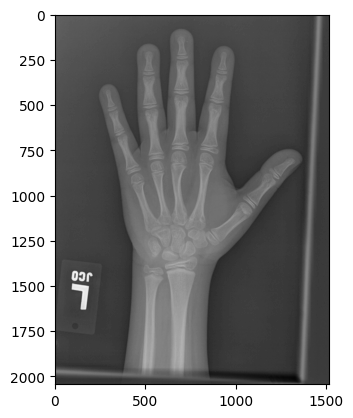

In [10]:
#Visualization
single_img = training_dataframe["path"][5]
imgs = imread(single_img)
plt.imshow(imgs, cmap = "gray")

PREPROCESSING

In [11]:
df_train, df_val = train_test_split(training_dataframe, test_size = 0.2, random_state=42, shuffle = True)
valid_df, df_test = train_test_split(df_val, test_size = 0.5, random_state=42, shuffle = True)

In [12]:
data_augmentation = dict(rotation_range=180,
                        zoom_range = 0.25,
                        brightness_range = [0.2,0.5],
                        width_shift_range = 0.2,
                        height_shift_range = 0.2,
                        horizontal_flip = True,
                        shear_range = 0.05,
                        fill_mode = "nearest")

train_generator = ImageDataGenerator(rescale=1/255, preprocessing_function = preprocess_input, **data_augmentation)
test_val_generator = ImageDataGenerator(rescale=1/255, preprocessing_function = preprocess_input)

In [13]:
img_size = (256,256)
batch_size = 32

train_data = train_generator.flow_from_dataframe(
    dataframe= df_train,
    x_col = "path",
    y_col = "boneage",
    batch_size = batch_size,
    seed = 42,
    shuffle = True,
    class_mode = "other",
    flip_vertical = True,
    color_mode = "rgb",
    target_size = img_size
)


valid_data = test_val_generator.flow_from_dataframe(
    dataframe= valid_df,
    x_col = "path",
    y_col = "boneage",
    batch_size = batch_size,
    seed = 42,
    shuffle = True,
    class_mode = "other",
    flip_vertical = True,
    color_mode = "rgb",
    target_size = img_size
    
)

test_data = test_val_generator.flow_from_dataframe(
    dataframe= df_test,
    x_col = "path",
    y_col = "boneage",
    batch_size = batch_size,
    seed = 42,
    shuffle = True,
    class_mode = "other",
    flip_vertical = True,
    color_mode = "rgb",
    target_size = img_size
    
)


Found 10088 validated image filenames.
Found 1261 validated image filenames.
Found 1262 validated image filenames.


In [14]:
X_test, y_test = next(test_val_generator.flow_from_dataframe(
    df_test,
    x_col="path",
    y_col="boneage",
    batch_size = 10*batch_size,
    class_mode = "other",
    flip_vertical = True,
    color_mode = "rgb",
    target_size = img_size
))

Found 1262 validated image filenames.


In [15]:
model = tf.keras.applications.xception.Xception(input_shape=(256,256,3), 
                                                include_top = False, 
                                                weights="imagenet")

model.trainable = True

I0000 00:00:1756552671.488970      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1756552671.489767      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [16]:
new_model = Sequential()
new_model.add(model)
new_model.add(GlobalMaxPooling2D())
new_model.add(Flatten())
new_model.add(Dense(5))
new_model.add(Activation("relu"))
new_model.add(Dense(1, activation="linear"))

new_model.compile(loss = "mse", optimizer= Adam(learning_rate = 0.001), metrics = ["mse"])

callback = EarlyStopping(monitor = "val_loss", restore_best_weights =True)

history = new_model.fit(train_data, epochs=10, validation_data = valid_data, batch_size = batch_size, callbacks =[callback])


Epoch 1/10


I0000 00:00:1756552716.116802      64 service.cc:148] XLA service 0x7e2fd4004d60 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1756552716.118746      64 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1756552716.118768      64 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1756552719.683993      64 cuda_dnn.cc:529] Loaded cuDNN version 90300
E0000 00:00:1756552735.777973      64 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1756552736.030167      64 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1756552737.731955      64 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. Th

 57/316 ━━━━━━━━━━━━━━━━━━━━ 7:45 2s/step - loss: 9404.1738 - mse: 9404.1738

E0000 00:00:1756552858.807712      64 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1756552858.969864      64 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1756552859.569551      64 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1756552859.723217      64 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1756552860.154751      64 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:0

316/316 ━━━━━━━━━━━━━━━━━━━━ 715s 2s/step - loss: 3607.6746 - mse: 3607.6746 - val_loss: 4315.9272 - val_mse: 4315.9272
Epoch 2/10
316/316 ━━━━━━━━━━━━━━━━━━━━ 542s 2s/step - loss: 440.1230 - mse: 440.1230 - val_loss: 410.0956 - val_mse: 410.0956
Epoch 3/10
316/316 ━━━━━━━━━━━━━━━━━━━━ 543s 2s/step - loss: 360.5226 - mse: 360.5226 - val_loss: 603.3667 - val_mse: 603.3667


MODEL EVALUATION

In [17]:
y_pred = new_model.predict(X_test, batch_size = 64, verbose = 1)

ord_ = np.argsort(y_test)
ord_ = np.array([1,45,67,89,91,109])

5/5 ━━━━━━━━━━━━━━━━━━━━ 18s 327ms/step


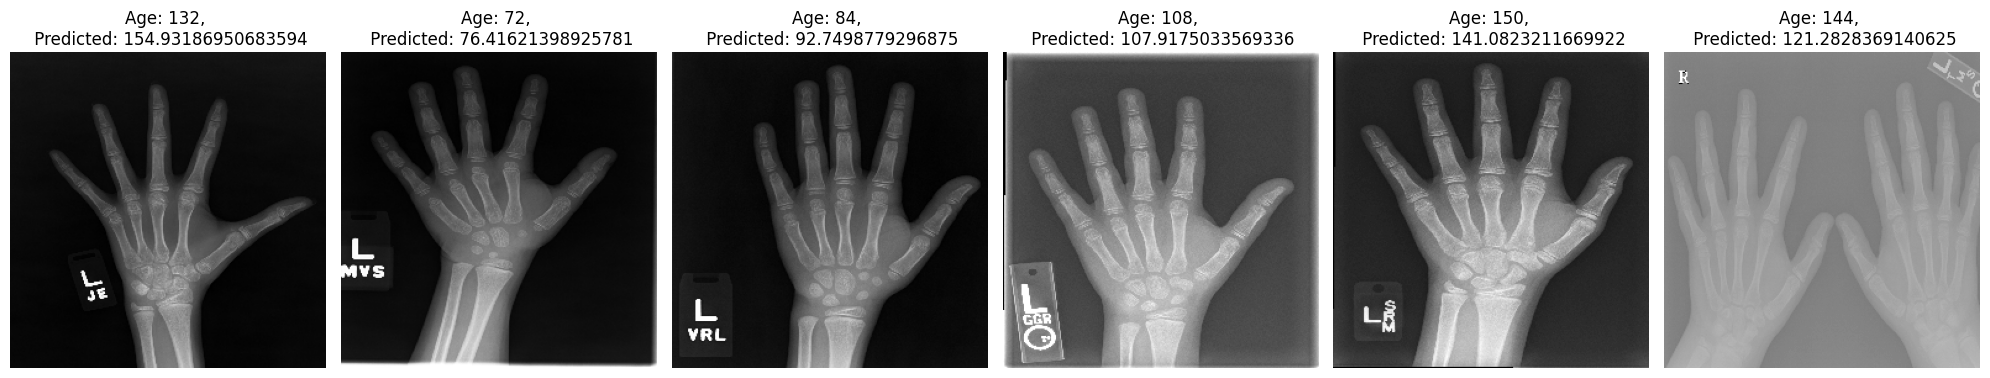

In [18]:
fig,ax = plt.subplots(1, 6, figsize = (20,20))

for(i, ax) in zip(ord_, ax.flatten()):
    ax.imshow(X_test[i,:,:,0], cmap = "gray")
    ax.set_title(f"Age: {y_test[i]}, \n Predicted: {y_pred[i][0]}")
    ax.axis("off")

plt.tight_layout()
plt.show()